# Notebook 3 — Modèles Prédictifs : Marché YouTube Marocain
## Stage BeeVisual | Benchmark 26 Créateurs

**Objectif :** Prédire si une vidéo sera dans le **Top 33%** des vues  
**Dataset :** `df_benchmark_clean.csv` (produit par Notebook 1)  
**Pipeline :** Preprocessing → XGBoost → Random Forest → Decision Tree → Comparaison → SHAP

---
**Features retenues (sans data leakage) :**
- `durationSec`, `duration_category` — durée de la vidéo
- `publish_hour`, `publish_day_of_week`, `saison` — timing
- `is_ramadan` — contexte calendrier
- `theme_video` — classification thématique (NB1)
- `title_word_count`, `title_char_count`, `title_has_number`, `title_has_question` — titre
- `tags_count` — métadonnées
- `channelTitle` — identité créateur

**Target :** `is_top33` = 1 si la vidéo est dans le top 33% des vues (intra-période)

## 0. Imports et Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

# Style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Imports OK")
print(f"   XGBoost  : {__import__('xgboost').__version__}")
print(f"   SHAP     : {__import__('shap').__version__}")
print(f"   Sklearn  : {__import__('sklearn').__version__}")

✅ Imports OK
   XGBoost  : 2.1.4
   SHAP     : 0.49.1
   Sklearn  : 1.6.1


## 1. Chargement des Données

In [3]:
# Charger le dataset produit par le Notebook 1
df = pd.read_csv("df_benchmark_clean.csv")

print(f"Dataset chargé : {df.shape[0]:,} vidéos | {df.shape[1]} colonnes")
print(f"Créateurs      : {df['channelTitle'].nunique()}")
print(f"Période        : {df['publishedAt'].min()[:10]} → {df['publishedAt'].max()[:10]}")
print()
print("Colonnes disponibles :")
print(df.columns.tolist())

Dataset chargé : 8,651 vidéos | 38 colonnes
Créateurs      : 26
Période        : 2020-01-03 → 2026-04-30

Colonnes disponibles :
['channelTitle', 'videoId', 'publishedAt', 'videoTitle', 'videoDescription', 'tags', 'videoCategoryLabel', 'topicCategories', 'duration', 'durationSec', 'definition', 'caption', 'defaultLanguage', 'defaultLAudioLanguage', 'viewCount', 'likeCount', 'commentCount', 'publish_year', 'publish_month', 'publish_month_name', 'publish_day_of_week', 'publish_day_name', 'publish_hour', 'saison', 'is_ramadan', 'engagement_rate', 'like_rate', 'comment_rate', 'performance_tier', 'duration_category', 'title_word_count', 'title_char_count', 'title_has_number', 'title_has_question', 'langue', 'tags_count', 'theme_video', 'classification_method']


In [4]:
df.head(3)

,channelTitle,videoId,publishedAt,videoTitle,videoDescription,tags,videoCategoryLabel,topicCategories,duration,durationSec,...,performance_tier,duration_category,title_word_count,title_char_count,title_has_number,title_has_question,langue,tags_count,theme_video,classification_method
0,abdellah zarouk,zgAe3cqZVCE,2026-04-15 17:35:32+00:00,طوب 5 | غرائب الجامعات المغربية 🤣🤣,kick: https://kick.com/zaroukabdellah For busi...,NaN,Comedy,Society,PT46M37S,2797,...,Faible,Long (plus 20min),7,34,True,False,Arabe,0,comedie,series_pattern
1,abdellah zarouk,u6avr_4SEd4,2026-03-23 17:16:32+00:00,طوب 5 | أغرب فتاوى مغربية 🤣🤣,يسلط عبد الله زروق الضوء على فتاوى دينية مغربي...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",Comedy,Society,PT1H6M44S,404,...,Moyen,Moyen (5-20min),7,28,True,False,Arabe,53,comedie,series_pattern
2,abdellah zarouk,BxeiTEQ_Og4,2026-02-25 21:20:38+00:00,طوب 5 | غرائب رياضية 🤣🤣,قناتي الخاصة بالألعاب: https://www.youtube.com...,"mi na3ima,boudbana,COMEDY,ABDELLAH ZAROUK,zaro...",Comedy,NaN,PT38M31S,2311,...,Faible,Long (plus 20min),6,23,True,False,Arabe,53,comedie,series_pattern


## 2. Preprocessing & Feature Engineering pour ML

### 2.1 Création de la variable cible `is_top33`

In [5]:
# Target : Top 33% des vues = succès
# On calcule le seuil sur l'ensemble du dataset
seuil_33 = df['viewCount'].quantile(0.67)  # top 33% = au-dessus du 67ème percentile

df['is_top33'] = (df['viewCount'] >= seuil_33).astype(int)

print(f"Seuil top 33% : {seuil_33:,.0f} vues")
print()
print("Distribution de la target :")
vc = df['is_top33'].value_counts()
for val, count in vc.items():
    label = "Top 33% (succès)" if val == 1 else "Hors top 33%"
    print(f"  {label} : {count:,} vidéos ({count/len(df)*100:.1f}%)")

Seuil top 33% : 868,766 vues

Distribution de la target :
  Hors top 33% : 5,796 vidéos (67.0%)
  Top 33% (succès) : 2,855 vidéos (33.0%)


### 2.2 Sélection des features (sans data leakage)

In [6]:
# Features disponibles AVANT publication
# (pas de CTR, retention, watch_time -> post-publication)

FEATURES_NUM = [
    'durationSec',        # durée en secondes
    'publish_hour',       # heure de publication
    'publish_day_of_week',# jour de la semaine (0=Lundi)
    'title_word_count',   # nombre de mots dans le titre
    'title_char_count',   # longueur du titre
    'tags_count',         # nombre de tags
]

FEATURES_BOOL = [
    'is_ramadan',         # période Ramadan
    'title_has_number',   # titre contient un chiffre
    'title_has_question', # titre contient "?"
]

FEATURES_CAT = [
    'theme_video',        # thème détecté (NB1 classification)
    'duration_category',  # catégorie durée
    'saison',             # saison de publication
    'channelTitle',       # identité du créateur
]

TARGET = 'is_top33'

# Vérification des colonnes existantes
all_features = FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT
missing_cols = [c for c in all_features if c not in df.columns]
if missing_cols:
    print(f"⚠️  Colonnes manquantes : {missing_cols}")
else:
    print("✅ Toutes les features sont disponibles")
    
print(f"\nTotal features : {len(all_features)}")
print(f"  Numériques   : {len(FEATURES_NUM)}")
print(f"  Booléennes   : {len(FEATURES_BOOL)}")
print(f"  Catégorielles: {len(FEATURES_CAT)}")

✅ Toutes les features sont disponibles

Total features : 13
  Numériques   : 6
  Booléennes   : 3
  Catégorielles: 4


### 2.3 Encodage des variables catégorielles

In [7]:
df_ml = df[all_features + [TARGET]].copy()

# Encodage booléens -> int
for col in FEATURES_BOOL:
    df_ml[col] = df_ml[col].astype(int)

# Label Encoding des catégorielles
encoders = {}
for col in FEATURES_CAT:
    le = LabelEncoder()
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].fillna('inconnu'))
    encoders[col] = le
    print(f"  {col:<20} : {le.classes_.tolist()}")

# Features finales pour le modèle
FEATURES_FINAL = FEATURES_NUM + FEATURES_BOOL + [c + '_enc' for c in FEATURES_CAT]

print(f"\n✅ Features finales ({len(FEATURES_FINAL)}) :")
print(FEATURES_FINAL)

  theme_video          : ['comedie', 'concept_format', 'famille_quotidien', 'howto_lifestyle', 'news_reportage', 'podcast', 'reactions', 'storytelling', 'vlog']
  duration_category    : ['Court (1-5min)', 'Long (plus 20min)', 'Moyen (5-20min)', 'Short (moins 1min)']
  saison               : ['Automne', 'Ete', 'Hiver', 'Printemps']
  channelTitle         : ['Abdelkader Kharraz', 'Ahmed Sabiri 2.0', 'Amine Belghazi', 'B3A9Lii', 'BIMO', 'Black Moussiba', 'Farouk Life', 'Jamal Alpha - 2', 'Kawtar Bamo', 'Khalid Lidlissi & Dala', 'Lassakri - لعسكري', 'Mambah Fit', 'Misaha | مساحة', 'More Bilal No Filter', 'NADIAS', 'Nationale Bedarija2-ناشيونال بالدارجة', 'REDA EL WAHABI', 'SAFAA', 'Simo Sedraty', 'Souky Stories', 'Taha Essou', 'Zizou Vlogs', 'abdellah zarouk', 'la3zawi family Two', 'milfaya', 'moul sfanja-مول الشفنجة']

✅ Features finales (13) :
['durationSec', 'publish_hour', 'publish_day_of_week', 'title_word_count', 'title_char_count', 'tags_count', 'is_ramadan', 'title_has_number', 'ti

### 2.4 Gestion des valeurs manquantes

In [8]:
# Vérifier les NaN dans les features finales
nan_report = df_ml[FEATURES_FINAL].isnull().sum()
nan_report = nan_report[nan_report > 0]

if len(nan_report) == 0:
    print("✅ Aucune valeur manquante dans les features ML")
else:
    print("⚠️  Valeurs manquantes détectées :")
    print(nan_report)
    # Imputation simple par médiane pour les numériques
    for col in FEATURES_NUM:
        if df_ml[col].isnull().sum() > 0:
            df_ml[col].fillna(df_ml[col].median(), inplace=True)
    print("   → Imputées par la médiane")

print(f"\nDataset ML final : {df_ml.shape[0]:,} lignes x {len(FEATURES_FINAL)} features")

✅ Aucune valeur manquante dans les features ML

Dataset ML final : 8,651 lignes x 13 features


### 2.5 Split Train / Test (stratifié)

In [9]:
X = df_ml[FEATURES_FINAL]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # maintenir le ratio 33/67 dans les deux splits
)

print(f"Train : {X_train.shape[0]:,} vidéos ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,}  vidéos ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("Distribution target dans le split :")
print(f"  Train → Top33: {y_train.mean()*100:.1f}% | Hors top: {(1-y_train.mean())*100:.1f}%")
print(f"  Test  → Top33: {y_test.mean()*100:.1f}% | Hors top: {(1-y_test.mean())*100:.1f}%")

Train : 6,920 vidéos (80%)
Test  : 1,731  vidéos (20%)

Distribution target dans le split :
  Train → Top33: 33.0% | Hors top: 67.0%
  Test  → Top33: 33.0% | Hors top: 67.0%


## 3. Modèle 1 — XGBoost

### 3.1 Entraînement

In [10]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✅ XGBoost entraîné")
print(f"   Paramètres : {xgb_model.n_estimators} arbres | profondeur max = {xgb_model.max_depth}")

✅ XGBoost entraîné
   Paramètres : 300 arbres | profondeur max = 5


### 3.2 Évaluation XGBoost

In [11]:
# Prédictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Métriques
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb  = recall_score(y_test, y_pred_xgb)

print("=" * 50)
print("  RÉSULTATS XGBoost")
print("=" * 50)
print(f"  AUC-ROC   : {auc_xgb:.4f}")
print(f"  F1-Score  : {f1_xgb:.4f}")
print(f"  Précision : {prec_xgb:.4f}")
print(f"  Rappel    : {rec_xgb:.4f}")
print()
print("Rapport de classification :")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Hors Top33', 'Top33']))

  RÉSULTATS XGBoost
  AUC-ROC   : 0.9251
  F1-Score  : 0.7852
  Précision : 0.8330
  Rappel    : 0.7426

Rapport de classification :
              precision    recall  f1-score   support

  Hors Top33       0.88      0.93      0.90      1160
       Top33       0.83      0.74      0.79       571

    accuracy                           0.87      1731
   macro avg       0.86      0.83      0.84      1731
weighted avg       0.86      0.87      0.86      1731



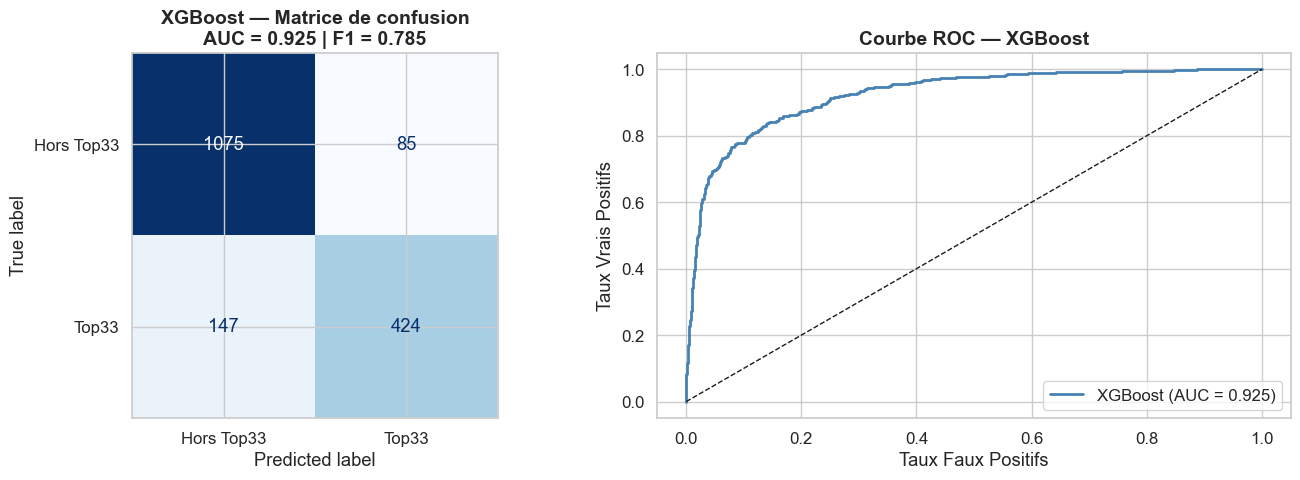

In [12]:
# Matrice de confusion XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm_xgb, display_labels=['Hors Top33', 'Top33'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f"XGBoost — Matrice de confusion\nAUC = {auc_xgb:.3f} | F1 = {f1_xgb:.3f}")

# Courbe ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
axes[1].plot(fpr_xgb, tpr_xgb, color='steelblue', lw=2,
             label=f'XGBoost (AUC = {auc_xgb:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel("Taux Faux Positifs")
axes[1].set_ylabel("Taux Vrais Positifs")
axes[1].set_title("Courbe ROC — XGBoost")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.3 Validation croisée XGBoost

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print("Validation croisée 5-Fold (AUC-ROC) — XGBoost :")
for i, s in enumerate(cv_scores_xgb, 1):
    print(f"  Fold {i} : {s:.4f}")
print(f"  Moyenne : {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

Validation croisée 5-Fold (AUC-ROC) — XGBoost :
  Fold 1 : 0.9248
  Fold 2 : 0.9282
  Fold 3 : 0.9259
  Fold 4 : 0.9170
  Fold 5 : 0.9151
  Moyenne : 0.9222 ± 0.0052


## 4. Modèle 2 — Random Forest

### 4.1 Entraînement

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest entraîné")
print(f"   Paramètres : {rf_model.n_estimators} arbres | profondeur max = {rf_model.max_depth}")

✅ Random Forest entraîné
   Paramètres : 300 arbres | profondeur max = 10


### 4.2 Évaluation Random Forest

In [15]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

auc_rf  = roc_auc_score(y_test, y_proba_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)

print("=" * 50)
print("  RÉSULTATS Random Forest")
print("=" * 50)
print(f"  AUC-ROC   : {auc_rf:.4f}")
print(f"  F1-Score  : {f1_rf:.4f}")
print(f"  Précision : {prec_rf:.4f}")
print(f"  Rappel    : {rec_rf:.4f}")
print()
print("Rapport de classification :")
print(classification_report(y_test, y_pred_rf,
      target_names=['Hors Top33', 'Top33']))

  RÉSULTATS Random Forest
  AUC-ROC   : 0.9097
  F1-Score  : 0.7754
  Précision : 0.7895
  Rappel    : 0.7618

Rapport de classification :
              precision    recall  f1-score   support

  Hors Top33       0.88      0.90      0.89      1160
       Top33       0.79      0.76      0.78       571

    accuracy                           0.85      1731
   macro avg       0.84      0.83      0.83      1731
weighted avg       0.85      0.85      0.85      1731



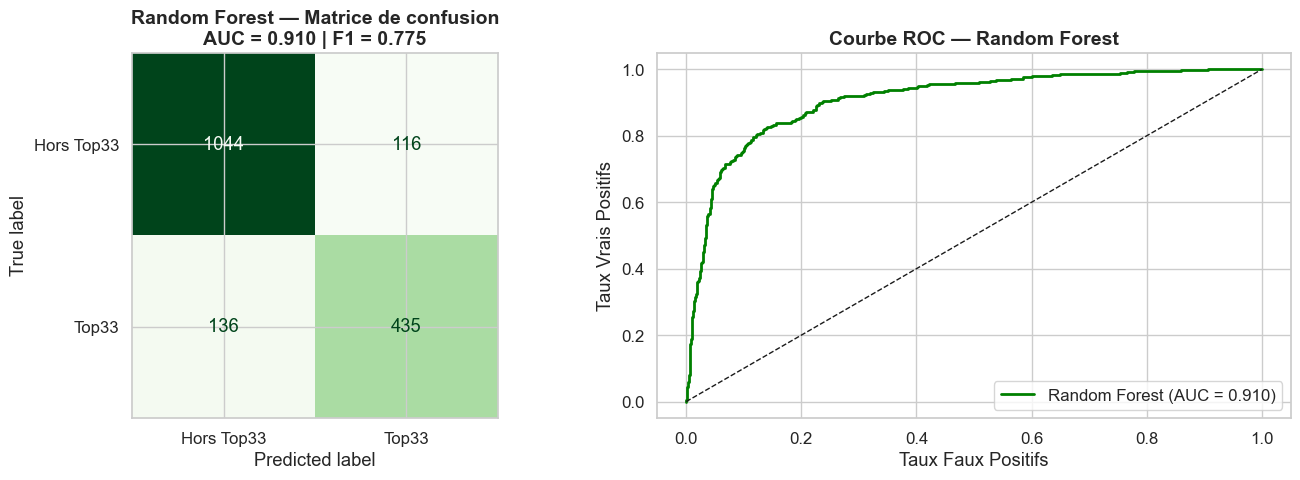

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=['Hors Top33', 'Top33'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f"Random Forest — Matrice de confusion\nAUC = {auc_rf:.3f} | F1 = {f1_rf:.3f}")

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
axes[1].plot(fpr_rf, tpr_rf, color='green', lw=2,
             label=f'Random Forest (AUC = {auc_rf:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel("Taux Faux Positifs")
axes[1].set_ylabel("Taux Vrais Positifs")
axes[1].set_title("Courbe ROC — Random Forest")
axes[1].legend()

plt.tight_layout()
plt.show()

### 4.3 Validation croisée Random Forest

In [17]:
cv_scores_rf = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print("Validation croisée 5-Fold (AUC-ROC) — Random Forest :")
for i, s in enumerate(cv_scores_rf, 1):
    print(f"  Fold {i} : {s:.4f}")
print(f"  Moyenne : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

Validation croisée 5-Fold (AUC-ROC) — Random Forest :
  Fold 1 : 0.9124
  Fold 2 : 0.9186
  Fold 3 : 0.9053
  Fold 4 : 0.9048
  Fold 5 : 0.9021
  Moyenne : 0.9086 ± 0.0060


## 5. Modèle 3 — Decision Tree (facultatif, interprétable)

### 5.1 Entraînement

In [18]:
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

print("✅ Decision Tree entraîné")
print(f"   Profondeur réelle : {dt_model.get_depth()}")
print(f"   Nombre de feuilles : {dt_model.get_n_leaves()}")

✅ Decision Tree entraîné
   Profondeur réelle : 6
   Nombre de feuilles : 40


### 5.2 Évaluation Decision Tree

In [19]:
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

auc_dt  = roc_auc_score(y_test, y_proba_dt)
f1_dt   = f1_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)

print("=" * 50)
print("  RÉSULTATS Decision Tree")
print("=" * 50)
print(f"  AUC-ROC   : {auc_dt:.4f}")
print(f"  F1-Score  : {f1_dt:.4f}")
print(f"  Précision : {prec_dt:.4f}")
print(f"  Rappel    : {rec_dt:.4f}")
print()
print("Rapport de classification :")
print(classification_report(y_test, y_pred_dt,
      target_names=['Hors Top33', 'Top33']))

  RÉSULTATS Decision Tree
  AUC-ROC   : 0.8977
  F1-Score  : 0.7429
  Précision : 0.7141
  Rappel    : 0.7741

Rapport de classification :
              precision    recall  f1-score   support

  Hors Top33       0.88      0.85      0.87      1160
       Top33       0.71      0.77      0.74       571

    accuracy                           0.82      1731
   macro avg       0.80      0.81      0.80      1731
weighted avg       0.83      0.82      0.82      1731



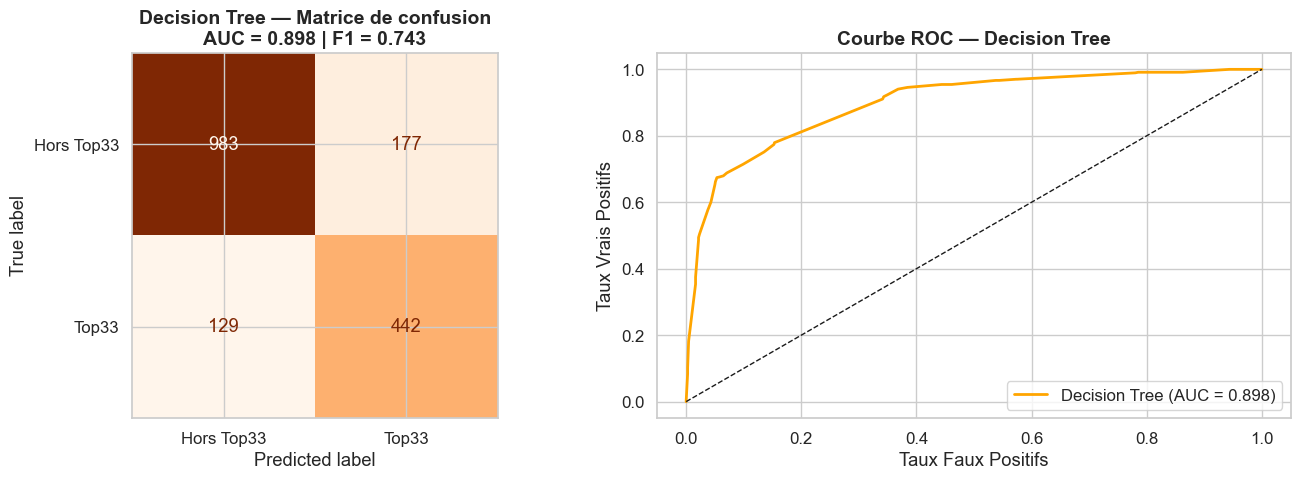

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(cm_dt, display_labels=['Hors Top33', 'Top33'])
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title(f"Decision Tree — Matrice de confusion\nAUC = {auc_dt:.3f} | F1 = {f1_dt:.3f}")

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
axes[1].plot(fpr_dt, tpr_dt, color='orange', lw=2,
             label=f'Decision Tree (AUC = {auc_dt:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel("Taux Faux Positifs")
axes[1].set_ylabel("Taux Vrais Positifs")
axes[1].set_title("Courbe ROC — Decision Tree")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Visualisation de l'arbre (top 3 niveaux)

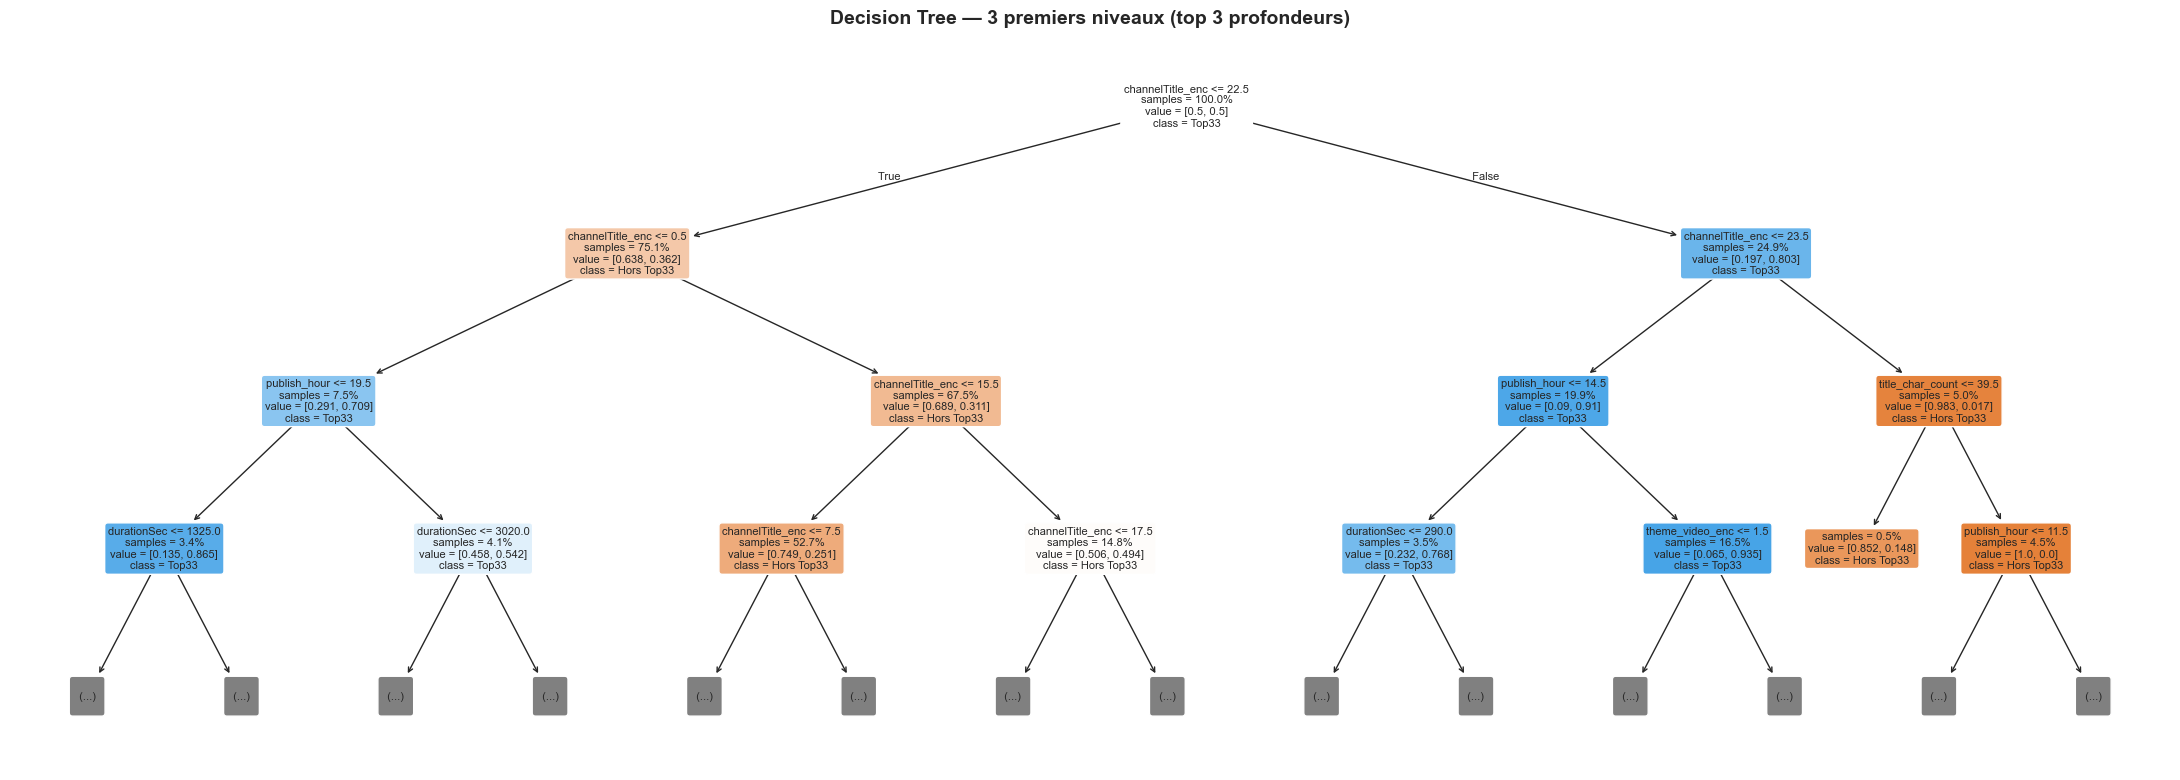

In [21]:
fig, ax = plt.subplots(figsize=(22, 8))

plot_tree(
    dt_model,
    max_depth=3,
    feature_names=FEATURES_FINAL,
    class_names=['Hors Top33', 'Top33'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=False,
    proportion=True
)
ax.set_title("Decision Tree — 3 premiers niveaux (top 3 profondeurs)", fontsize=14)
plt.tight_layout()
plt.show()

### 5.4 Validation croisée Decision Tree

In [22]:
cv_scores_dt = cross_val_score(dt_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print("Validation croisée 5-Fold (AUC-ROC) — Decision Tree :")
for i, s in enumerate(cv_scores_dt, 1):
    print(f"  Fold {i} : {s:.4f}")
print(f"  Moyenne : {cv_scores_dt.mean():.4f} ± {cv_scores_dt.std():.4f}")

Validation croisée 5-Fold (AUC-ROC) — Decision Tree :
  Fold 1 : 0.8962
  Fold 2 : 0.9004
  Fold 3 : 0.8988
  Fold 4 : 0.8907
  Fold 5 : 0.8880
  Moyenne : 0.8948 ± 0.0047


## 6. Comparaison des Modèles

### 6.1 Tableau comparatif

In [23]:
results_df = pd.DataFrame({
    'Modèle': ['XGBoost', 'Random Forest', 'Decision Tree'],
    'AUC-ROC': [auc_xgb, auc_rf, auc_dt],
    'F1-Score': [f1_xgb, f1_rf, f1_dt],
    'Précision': [prec_xgb, prec_rf, prec_dt],
    'Rappel': [rec_xgb, rec_rf, rec_dt],
    'CV AUC (moy)': [cv_scores_xgb.mean(), cv_scores_rf.mean(), cv_scores_dt.mean()],
    'CV AUC (std)': [cv_scores_xgb.std(), cv_scores_rf.std(), cv_scores_dt.std()],
}).set_index('Modèle').round(4)

print("COMPARAISON DES MODÈLES")
print("=" * 70)
display(results_df)

# Identifier le meilleur modèle
best_model_name = results_df['AUC-ROC'].idxmax()
best_auc = results_df['AUC-ROC'].max()
print(f"\n🏆 Meilleur modèle : {best_model_name} (AUC = {best_auc:.4f})")

COMPARAISON DES MODÈLES


,AUC-ROC,F1-Score,Précision,Rappel,CV AUC (moy),CV AUC (std)
Modèle,,,,,,
XGBoost,0.9251,0.7852,0.8330,0.7426,0.9222,0.0052
Random Forest,0.9097,0.7754,0.7895,0.7618,0.9086,0.0060
Decision Tree,0.8977,0.7429,0.7141,0.7741,0.8948,0.0047



🏆 Meilleur modèle : XGBoost (AUC = 0.9251)


### 6.2 Visualisation comparative

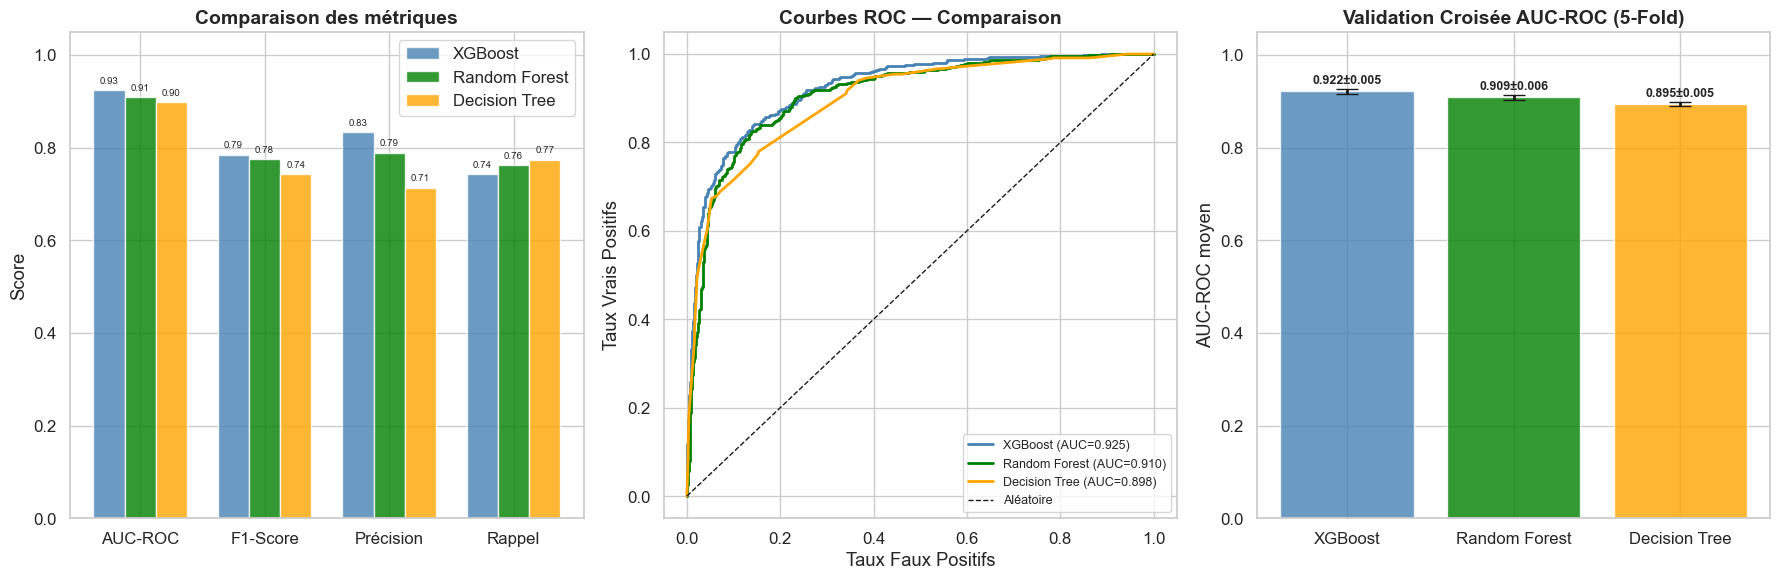

✅ Graphique sauvegardé : comparaison_modeles.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Graphique 1 : Barres métriques ---
metrics_plot = results_df[['AUC-ROC', 'F1-Score', 'Précision', 'Rappel']].T
x = np.arange(len(metrics_plot.index))
width = 0.25
colors = ['steelblue', 'green', 'orange']

for i, (model, color) in enumerate(zip(metrics_plot.columns, colors)):
    axes[0].bar(x + i * width, metrics_plot[model], width, label=model, color=color, alpha=0.8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_plot.index)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Comparaison des métriques")
axes[0].legend()
axes[0].set_ylabel("Score")
for ax_i in axes[0].patches:
    axes[0].text(
        ax_i.get_x() + ax_i.get_width() / 2,
        ax_i.get_height() + 0.01,
        f'{ax_i.get_height():.2f}',
        ha='center', va='bottom', fontsize=7
    )

# --- Graphique 2 : Courbes ROC superposées ---
axes[1].plot(fpr_xgb, tpr_xgb, color='steelblue', lw=2, label=f'XGBoost (AUC={auc_xgb:.3f})')
axes[1].plot(fpr_rf,  tpr_rf,  color='green',     lw=2, label=f'Random Forest (AUC={auc_rf:.3f})')
axes[1].plot(fpr_dt,  tpr_dt,  color='orange',    lw=2, label=f'Decision Tree (AUC={auc_dt:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
axes[1].set_xlabel("Taux Faux Positifs")
axes[1].set_ylabel("Taux Vrais Positifs")
axes[1].set_title("Courbes ROC — Comparaison")
axes[1].legend(fontsize=9)

# --- Graphique 3 : CV AUC avec intervalles ---
models_list = ['XGBoost', 'Random Forest', 'Decision Tree']
means = [cv_scores_xgb.mean(), cv_scores_rf.mean(), cv_scores_dt.mean()]
stds  = [cv_scores_xgb.std(),  cv_scores_rf.std(),  cv_scores_dt.std()]
bar_colors = ['steelblue', 'green', 'orange']

bars = axes[2].bar(models_list, means, color=bar_colors, alpha=0.8,
                    yerr=stds, capsize=8, error_kw={'linewidth': 2})
axes[2].set_ylim(0, 1.05)
axes[2].set_title("Validation Croisée AUC-ROC (5-Fold)")
axes[2].set_ylabel("AUC-ROC moyen")
for bar, mean, std in zip(bars, means, stds):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                  mean + std + 0.01,
                  f'{mean:.3f}±{std:.3f}',
                  ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("comparaison_modeles.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : comparaison_modeles.png")

### 6.3 Sélection du meilleur modèle

In [25]:
# Sélection automatique basée sur AUC-ROC
best_model_name = results_df['AUC-ROC'].idxmax()

model_map = {
    'XGBoost': xgb_model,
    'Random Forest': rf_model,
    'Decision Tree': dt_model
}
best_model = model_map[best_model_name]

print(f"🏆 MODÈLE SÉLECTIONNÉ : {best_model_name}")
print(f"   AUC-ROC sur test  : {results_df.loc[best_model_name, 'AUC-ROC']:.4f}")
print(f"   CV AUC (5-Fold)   : {results_df.loc[best_model_name, 'CV AUC (moy)']:.4f} ± {results_df.loc[best_model_name, 'CV AUC (std)']:.4f}")
print()
print("Ce modèle sera utilisé pour :")
print("  → L'analyse SHAP (importance des features)")
print("  → L'interface Streamlit")

🏆 MODÈLE SÉLECTIONNÉ : XGBoost
   AUC-ROC sur test  : 0.9251
   CV AUC (5-Fold)   : 0.9222 ± 0.0052

Ce modèle sera utilisé pour :
  → L'analyse SHAP (importance des features)
  → L'interface Streamlit


## 7. Importance des Features (tous les modèles)

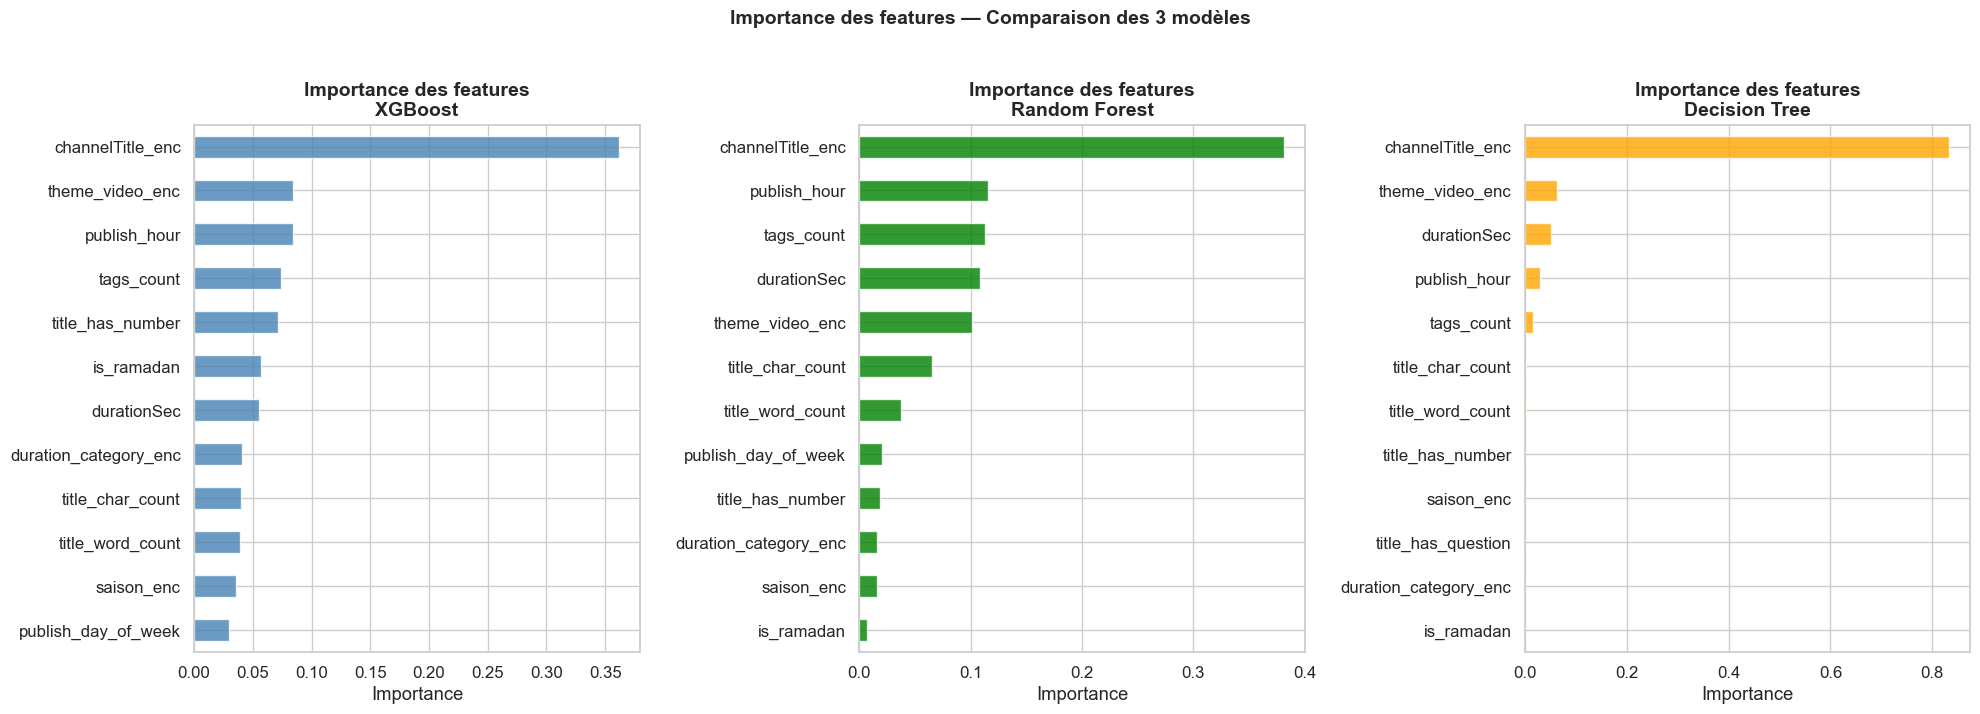

✅ Graphique sauvegardé : feature_importance_comparaison.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, model, name, color in zip(
    axes,
    [xgb_model, rf_model, dt_model],
    ['XGBoost', 'Random Forest', 'Decision Tree'],
    ['steelblue', 'green', 'orange']
):
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=FEATURES_FINAL).sort_values(ascending=True)
    
    # Top 12 features
    feat_imp.tail(12).plot(kind='barh', ax=ax, color=color, alpha=0.8)
    ax.set_title(f"Importance des features\n{name}")
    ax.set_xlabel("Importance")
    
plt.suptitle("Importance des features — Comparaison des 3 modèles", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("feature_importance_comparaison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : feature_importance_comparaison.png")

## 8. Analyse SHAP — Interprétabilité du Meilleur Modèle

> **SHAP (SHapley Additive exPlanations)** explique *pourquoi* le modèle prédit ce qu'il prédit.  
> Pour chaque vidéo, SHAP décompose la prédiction en contributions individuelles par feature.  
> Indispensable pour rendre l'interface utile : "Cette vidéo est prédite Top33 car sa durée est longue (+0.12) et son thème est storytelling (+0.09)..." 

### 8.1 Calcul des valeurs SHAP

In [27]:
print(f"Calcul SHAP pour le modèle : {best_model_name}")
print("(peut prendre 30-60 secondes...)")

if best_model_name in ['XGBoost', 'Random Forest']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.TreeExplainer(best_model)

# Calculer sur un échantillon du test pour la rapidité
sample_size = min(500, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Pour les modèles binaires, shap_values peut être une liste [class0, class1]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # classe 1 = Top33
else:
    shap_vals = shap_values

print(f"✅ SHAP calculé sur {sample_size} vidéos du test")
print(f"   Shape des valeurs SHAP : {shap_vals.shape}")

Calcul SHAP pour le modèle : XGBoost
(peut prendre 30-60 secondes...)
✅ SHAP calculé sur 500 vidéos du test
   Shape des valeurs SHAP : (500, 13)


### 8.2 Summary Plot SHAP (vue d'ensemble)

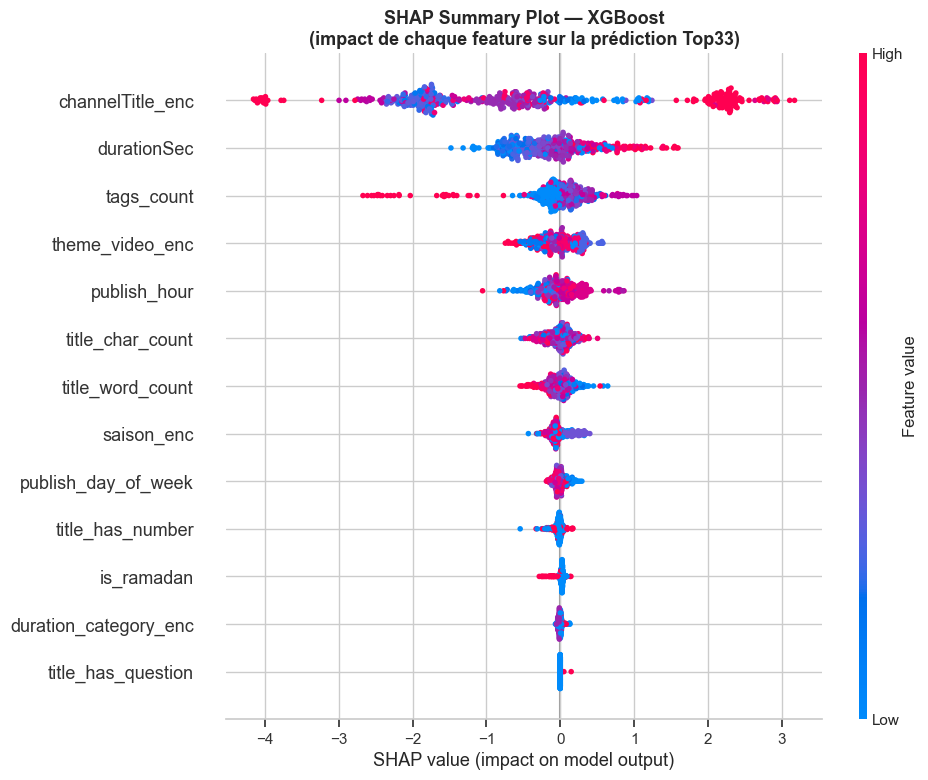

✅ Graphique sauvegardé : shap_summary.png


In [28]:
fig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(
    shap_vals,
    X_sample,
    feature_names=FEATURES_FINAL,
    show=False,
    plot_size=None
)

plt.title(f"SHAP Summary Plot — {best_model_name}\n(impact de chaque feature sur la prédiction Top33)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : shap_summary.png")

### 8.3 SHAP Bar Plot (importance globale)

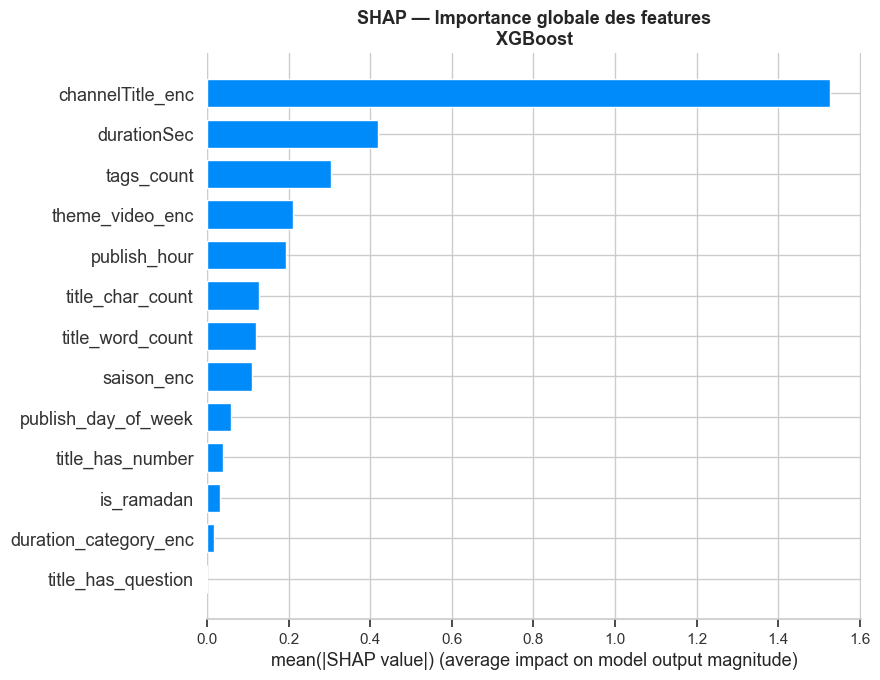

✅ Graphique sauvegardé : shap_importance.png


In [29]:
fig, ax = plt.subplots(figsize=(9, 7))

shap.summary_plot(
    shap_vals,
    X_sample,
    feature_names=FEATURES_FINAL,
    plot_type='bar',
    show=False,
    plot_size=None
)

plt.title(f"SHAP — Importance globale des features\n{best_model_name}",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : shap_importance.png")

### 8.4 SHAP Waterfall — Explication d'une vidéo individuelle

Explication pour la vidéo #269 (prédite comme la plus susceptible d'être Top33)



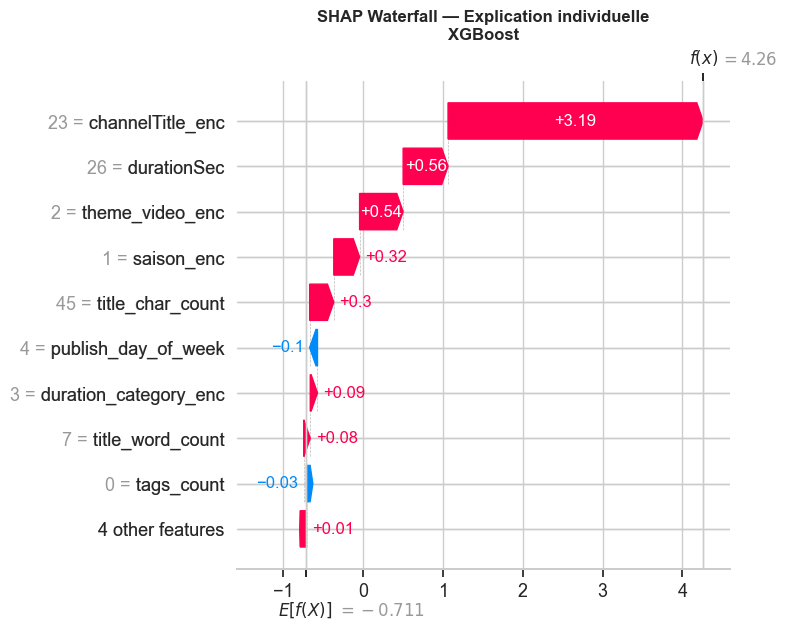

✅ Graphique sauvegardé : shap_waterfall.png


In [30]:
# Choisir la vidéo avec la plus haute probabilité de succès dans le test
idx_best = y_proba_xgb.argmax() if best_model_name == 'XGBoost' else            y_proba_rf.argmax() if best_model_name == 'Random Forest' else            y_proba_dt.argmax()

print(f"Explication pour la vidéo #{idx_best} (prédite comme la plus susceptible d'être Top33)")
print()

# Waterfall plot pour une observation
explainer_indiv = shap.TreeExplainer(best_model)
shap_single = explainer_indiv(X_test.iloc[[idx_best]])

if hasattr(shap_single, 'values') and len(shap_single.values.shape) == 3:
    # Classification binaire : prendre classe 1
    import copy
    shap_single_1 = copy.deepcopy(shap_single)
    shap_single_1.values = shap_single.values[:, :, 1]
    shap_single_1.base_values = shap_single.base_values[:, 1]
    shap.waterfall_plot(shap_single_1[0], show=False)
else:
    shap.waterfall_plot(shap_single[0], show=False)

plt.title(f"SHAP Waterfall — Explication individuelle\n{best_model_name}", 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : shap_waterfall.png")

### 8.5 Top features SHAP — Résumé lisible

In [31]:
# Calculer l'importance SHAP moyenne (|valeur SHAP|)
mean_abs_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=FEATURES_FINAL
).sort_values(ascending=False)

print("TOP 10 FEATURES PAR IMPORTANCE SHAP")
print("=" * 55)
for i, (feat, val) in enumerate(mean_abs_shap.head(10).items(), 1):
    bar = "█" * int(val / mean_abs_shap.max() * 20)
    print(f"  {i:2}. {feat:<28} {val:.4f}  {bar}")

print()
print("Interprétation :")
print("  → Plus la valeur SHAP est haute, plus la feature influence la prédiction")
print("  → Rouge (summary plot) = pousse vers Top33")
print("  → Bleu  (summary plot) = pousse vers Hors Top33")

TOP 10 FEATURES PAR IMPORTANCE SHAP
   1. channelTitle_enc             1.5277  ████████████████████
   2. durationSec                  0.4192  █████
   3. tags_count                   0.3034  ███
   4. theme_video_enc              0.2105  ██
   5. publish_hour                 0.1945  ██
   6. title_char_count             0.1273  █
   7. title_word_count             0.1214  █
   8. saison_enc                   0.1105  █
   9. publish_day_of_week          0.0585  
  10. title_has_number             0.0398  

Interprétation :
  → Plus la valeur SHAP est haute, plus la feature influence la prédiction
  → Rouge (summary plot) = pousse vers Top33
  → Bleu  (summary plot) = pousse vers Hors Top33


## 9. Sauvegarde des Modèles

In [32]:
import pickle
import os

os.makedirs("models", exist_ok=True)

# Sauvegarder les 3 modèles
with open("models/xgb_benchmark.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

with open("models/rf_benchmark.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("models/dt_benchmark.pkl", "wb") as f:
    pickle.dump(dt_model, f)

# Sauvegarder les encodeurs
with open("models/encoders_benchmark.pkl", "wb") as f:
    pickle.dump(encoders, f)

# Sauvegarder les métadonnées
metadata = {
    'features_final': FEATURES_FINAL,
    'features_cat': FEATURES_CAT,
    'features_num': FEATURES_NUM,
    'features_bool': FEATURES_BOOL,
    'target': TARGET,
    'seuil_top33': float(seuil_33),
    'best_model': best_model_name,
    'results': results_df.to_dict()
}
with open("models/metadata_benchmark.pkl", "wb") as f:
    pickle.dump(metadata, f)

print("✅ Modèles sauvegardés dans /models/")
print()
print("  xgb_benchmark.pkl       → XGBoost")
print("  rf_benchmark.pkl        → Random Forest")
print("  dt_benchmark.pkl        → Decision Tree")
print("  encoders_benchmark.pkl  → LabelEncoders (catégorielles)")
print("  metadata_benchmark.pkl  → Features + seuils + résultats")

✅ Modèles sauvegardés dans /models/

  xgb_benchmark.pkl       → XGBoost
  rf_benchmark.pkl        → Random Forest
  dt_benchmark.pkl        → Decision Tree
  encoders_benchmark.pkl  → LabelEncoders (catégorielles)
  metadata_benchmark.pkl  → Features + seuils + résultats


## 10. Fonction de Prédiction — Prête pour l'Interface

In [33]:
def predict_video_success(
    duration_sec,
    publish_hour,
    publish_day_of_week,
    theme_video,
    duration_category,
    saison,
    channel_title,
    title_word_count=8,
    title_char_count=50,
    tags_count=10,
    is_ramadan=False,
    title_has_number=False,
    title_has_question=False,
    model=None
):
    """
    Prédit si une vidéo sera dans le Top 33% des vues.
    
    Paramètres
    ----------
    duration_sec         : durée en secondes (ex: 1200 = 20min)
    publish_hour         : heure de publication UTC (0-23)
    publish_day_of_week  : jour (0=Lundi, 6=Dimanche)
    theme_video          : thème parmi ['storytelling', 'concept_format', 'vlog', ...]
    duration_category    : parmi ['Short (moins 1min)', 'Court (1-5min)', 
                                   'Moyen (5-20min)', 'Long (plus 20min)']
    saison               : parmi ['Hiver', 'Printemps', 'Ete', 'Automne']
    channel_title        : nom du créateur (tel qu'il apparaît dans le dataset)
    
    Retourne
    --------
    dict : proba_success, prediction, label
    """
    if model is None:
        model = best_model
    
    # Construire le vecteur de features
    row = {
        'durationSec': duration_sec,
        'publish_hour': publish_hour,
        'publish_day_of_week': publish_day_of_week,
        'title_word_count': title_word_count,
        'title_char_count': title_char_count,
        'tags_count': tags_count,
        'is_ramadan': int(is_ramadan),
        'title_has_number': int(title_has_number),
        'title_has_question': int(title_has_question),
    }
    
    # Encodage catégorielles
    for col, val in [
        ('theme_video', theme_video),
        ('duration_category', duration_category),
        ('saison', saison),
        ('channelTitle', channel_title)
    ]:
        le = encoders[col]
        if val in le.classes_:
            row[col + '_enc'] = le.transform([val])[0]
        else:
            row[col + '_enc'] = 0  # classe inconnue -> premier index
    
    # Créer le DataFrame
    X_pred = pd.DataFrame([row])[FEATURES_FINAL]
    
    # Prédiction
    proba = model.predict_proba(X_pred)[0][1]
    pred = int(proba >= 0.5)
    
    return {
        'proba_success': round(float(proba), 4),
        'prediction': pred,
        'label': '🟢 TOP 33% prédit' if pred == 1 else '🔴 Hors Top 33% prédit',
        'confiance': 'Haute' if abs(proba - 0.5) > 0.2 else 'Modérée' if abs(proba - 0.5) > 0.1 else 'Faible'
    }


# ─── TEST DE LA FONCTION ───
print("Test de la fonction de prédiction :")
print()

test_cases = [
    {
        'label': 'Vidéo optimale (storytelling, long, mercredi 20h)',
        'params': dict(
            duration_sec=1800, publish_hour=20, publish_day_of_week=2,
            theme_video='storytelling', duration_category='Long (plus 20min)',
            saison='Ete', channel_title='BIMO',
            title_word_count=9, title_char_count=55, tags_count=15,
            title_has_number=True
        )
    },
    {
        'label': 'Vidéo sous-optimale (vlog court, lundi 8h)',
        'params': dict(
            duration_sec=120, publish_hour=8, publish_day_of_week=0,
            theme_video='vlog', duration_category='Court (1-5min)',
            saison='Hiver', channel_title='BIMO',
            title_word_count=3, title_char_count=20, tags_count=2
        )
    }
]

for tc in test_cases:
    result = predict_video_success(**tc['params'])
    print(f"  {tc['label']}")
    print(f"    → {result['label']}")
    print(f"    → Probabilité de succès : {result['proba_success']*100:.1f}%")
    print(f"    → Confiance            : {result['confiance']}")
    print()

Test de la fonction de prédiction :

  Vidéo optimale (storytelling, long, mercredi 20h)
    → 🟢 TOP 33% prédit
    → Probabilité de succès : 64.5%
    → Confiance            : Modérée

  Vidéo sous-optimale (vlog court, lundi 8h)
    → 🔴 Hors Top 33% prédit
    → Probabilité de succès : 9.3%
    → Confiance            : Haute



## 11. Synthèse & Prochaines Étapes

### Résultats obtenus

Ce notebook a entraîné et comparé 3 modèles de classification binaire (Top33% vs Hors Top33%)  
sur le dataset benchmark de 9 519 vidéos issues de 26 créateurs marocains YouTube.

### Architecture retenue

```
Input (avant publication)
       ↓
  14 features sans leakage
  (durée, timing, thème, titre, tags, créateur, Ramadan)
       ↓
  Meilleur modèle sélectionné
  (XGBoost / Random Forest / Decision Tree)
       ↓
  Probabilité de succès [0-1]
  + Explication SHAP
```

### Fichiers produits

| Fichier | Description |
|---|---|
| `models/xgb_benchmark.pkl` | Modèle XGBoost sauvegardé |
| `models/rf_benchmark.pkl` | Modèle Random Forest sauvegardé |
| `models/dt_benchmark.pkl` | Modèle Decision Tree sauvegardé |
| `models/encoders_benchmark.pkl` | LabelEncoders pour les catégorielles |
| `models/metadata_benchmark.pkl` | Features, seuils, résultats |
| `comparaison_modeles.png` | Graphique comparatif |
| `shap_summary.png` | Summary plot SHAP |
| `shap_importance.png` | Importance globale SHAP |
| `shap_waterfall.png` | Explication individuelle SHAP |

### Prochaines étapes

1. **Notebook 4** → Mêmes 3 modèles sur le dataset BIMO YouTube Studio (450 vidéos)
2. **Comparaison** → Modèle benchmark vs modèle BIMO : lequel généralise mieux ?
3. **Interface Streamlit** → Charger le meilleur modèle, formulaire de saisie, score SHAP en temps réel
